In [ ]:
# failed locally

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices())


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
import os

PROJECT_ROOT = "/Users/harshith/Downloads/Projects/deepfake_voice_iot"
os.chdir(PROJECT_ROOT)

print("Current working directory:")
print(os.getcwd())


Current working directory:
/Users/harshith/Downloads/Projects/deepfake_voice_iot


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())


TensorFlow version: 2.15.0
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
import numpy as np

X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")

X_dev = np.load("data/X_dev.npy")
y_dev = np.load("data/y_dev.npy")

print(X_train.shape, y_train.shape)
print(X_dev.shape, y_dev.shape)


(25380, 154, 400) (25380,)
(24844, 154, 400) (24844,)


In [5]:
print("Train labels:", len(y_train))
print("Dev labels  :", len(y_dev))
print("Unique dev labels:", np.unique(y_dev, return_counts=True))


Train labels: 25380
Dev labels  : 24844
Unique dev labels: (array([0, 1], dtype=int32), array([22296,  2548]))


In [6]:
X_train = X_train[..., np.newaxis]
X_dev = X_dev[..., np.newaxis]

print("After reshape:")
print("X_train:", X_train.shape)
print("X_dev  :", X_dev.shape)


After reshape:
X_train: (25380, 154, 400, 1)
X_dev  : (24844, 154, 400, 1)


In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(154, 400, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 154, 400, 32)      320       
                                                                 
 batch_normalization (Batch  (None, 154, 400, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 77, 200, 32)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 77, 200, 64)       18496     
                                                                 
 batch_normalization_1 (Bat  (None, 77, 200, 64)       256       
 chNormalization)                                                
                                                        

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [9]:
class EpochLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"✅ Epoch {epoch + 1} completed "
              f"- loss: {logs['loss']:.4f}, "
              f"acc: {logs['accuracy']:.4f}, "
              f"val_loss: {logs['val_loss']:.4f}, "
              f"val_acc: {logs['val_accuracy']:.4f}")


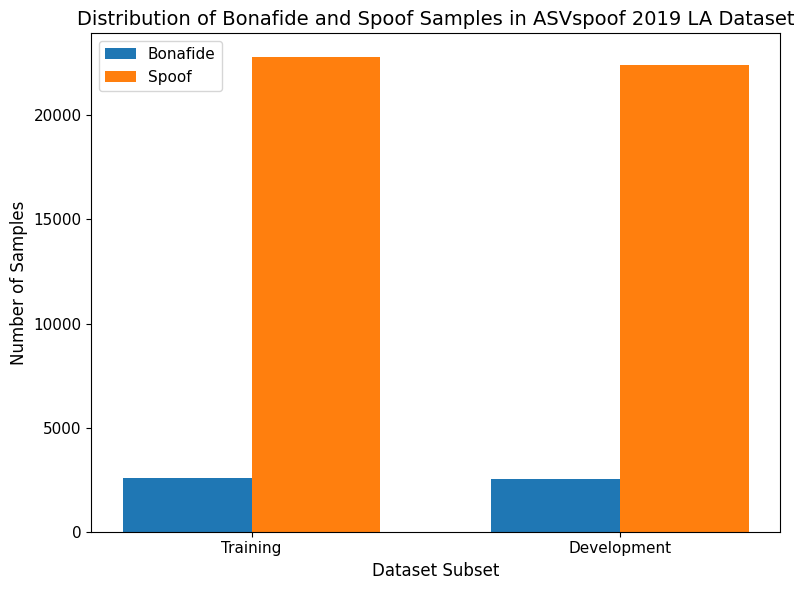

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset values from ASVspoof 2019 LA
subsets = ["Training", "Development"]
bonafide = [2580, 2548]
spoof = [22800, 22438]

x = np.arange(len(subsets))
width = 0.35

# Increased figure size
plt.figure(figsize=(8, 6))

plt.bar(x - width/2, bonafide, width, label="Bonafide")
plt.bar(x + width/2, spoof, width, label="Spoof")

# Increased font sizes
plt.xlabel("Dataset Subset", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title(
    "Distribution of Bonafide and Spoof Samples in ASVspoof 2019 LA Dataset",
    fontsize=14
)

plt.xticks(x, subsets, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)

plt.tight_layout()

# High-resolution image for paper
plt.savefig("dataset_distribution.png", dpi=300)
plt.show()


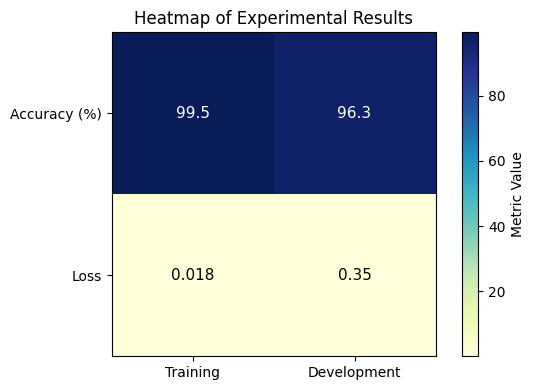

In [24]:
import matplotlib.pyplot as plt
import numpy as np

data = np.array([
    [99.5, 96.3],
    [0.018, 0.35]
])

rows = ['Accuracy (%)', 'Loss']
cols = ['Training', 'Development']

plt.figure(figsize=(6,4))
plt.imshow(data, cmap='YlGnBu')

plt.xticks(np.arange(len(cols)), cols)
plt.yticks(np.arange(len(rows)), rows)

# Add values with conditional text color
for i in range(len(rows)):
    for j in range(len(cols)):
        text_color = 'white' if i == 0 else 'black'  # Accuracy row in white
        plt.text(j, i, data[i, j], ha='center', va='center', color=text_color, fontsize=11)

plt.colorbar(label='Metric Value')
plt.title('Heatmap of Experimental Results')

plt.tight_layout()
plt.savefig("results_heatmap.png", dpi=300)
plt.show()
